# X-Set Enrichment Analysis (XSEA; c.f. ABAnnotate)

So far, we've been computing colocalization values between a brain map and individual reference maps — one correlation per receptor or gene. But sometimes we don't care about individual maps; we want to know whether the brain pattern of interest is broadly associated with a *group* of maps — say, all serotonin receptors, or all genes expressed in excitatory neurons.

This is the idea behind **X-Set Enrichment Analysis (XSEA)**. The concept is closely related to Gene Set Enrichment Analysis (GSEA) in transcriptomics, adapted for brain maps.

The concept of XSEA used here was first implemented in the MATLAB toolbox [**ABAnnotate**](https://github.com/leondlotter/ABAnnotate), a predecessor of NiSpace. If you've used ABAnnotate, you'll find the concepts familiar.

## The idea

Given a brain map and a set of reference maps (e.g., all receptor maps for serotonin), XSEA computes:

1. The mean colocalization between the brain map and all maps in the set.
2. A p-value asking: is this mean colocalization higher than expected when the brain map is replaced by a spatially-constrained random map?

The result is one statistic per *set*, not per individual map.

## A note on null models

There are two natural null hypotheses for XSEA:

1. **Permute the input map** (default): generate surrogate maps of the brain map and recompute mean colocalizations. This tests whether the observed mean is higher than expected under spatial randomness.
2. **Permute the sets**: randomly sample sets from a larger background population of maps and ask whether the observed set mean is higher than random sets.

Ben Fulcher et al. (2021, *Nature Communications*) showed that random set sampling can inflate false positives when maps within a set are highly co-expressed (correlated). NiSpace therefore defaults to map permutation, following the approach of ABAnnotate. Pass `permute_sets=True` to switch to set permutation if needed. However, this is currently not recommended. In the future, we will implement within-set correlation-matched set resampling, which can address this issue.

In [2]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import numpy as np
import pandas as pd

In [3]:
from nispace.datasets import fetch_reference, fetch_example
from nispace.io import load_img
from nispace.api import NiSpace

## Dataset setup

We'll run XSEA on the pain map against mRNA gene expression data, testing whether pain-related brain activation broadly aligns with the expression of particular cell types.

The mRNA reference dataset is derived from the Allen Human Brain Atlas (AHBA) and provides mean gene expression per brain region for thousands of genes, organized into sets such as cell type markers.

In [4]:
# pain map (NeuroQuery meta-analytic z-map)
pain_map = load_img("neuroquery/pain.nii.gz")

# mRNA reference: cell type marker sets (Lake et al 2016)
# parcellation: Yan100+TianS1 (low resolution to match coarse ABA data sampling)
mrna = fetch_reference(
    "mrna",
    parcellation="Yan100+TianS1",
    collection="CellTypesPsychEncodeTPM",
    print_references=False
)
print(f"mRNA data: {mrna.shape[0]} genes across {mrna.index.get_level_values('set').nunique()} sets x {mrna.shape[1]} parcels")
print(f"Set names: {list(mrna.index.get_level_values('set').unique())}")
mrna.head(3)

INFO | 30/06/26 13:09:58 | nispace.datasets: Loading mrna maps.


INFO | 30/06/26 13:09:58 | nispace.datasets: Loading integrated collection 'CellTypesPsychEncodeTPM' for dataset 'mrna'.


INFO | 30/06/26 13:09:58 | nispace.datasets: Filtering maps by collection.


INFO | 30/06/26 13:09:58 | nispace.datasets: Loading and inner-merging data parcellated with 'Yan100' and 'TianS1'


mRNA data: 465 genes across 24 sets x 116 parcels
Set names: ['Ex1 CortProject (L2/3)', 'Ex2 Granule (L3/4)', 'Ex3 Granule (L4)', 'Ex4 SubcortProject (L4)', 'Ex5 SubcortProject (L4-6)', 'Ex6 SubcortProject (L5-6)', 'Ex7 Corticothalamic', 'Ex8 Corticothalamic (L6)', 'In1 VIP+RELN+NDNF+ (L1/2)', 'In2 VIP+RELN-NDNF- (L6)', 'In3 VIP+RELN+NDNF- (L6)', 'In4 VIP-RELN+NDNF+ (L1-3)', 'In5 CCK+NOS1+CALB2+ (L2/3)', 'In6 PVALB+CRHBP+ (L4/5)', 'In7 SST+CALB1+NPY+ (L5/6)', 'In8 SST+NOS1+ (L6)', 'Astrocyte', 'Endothelial', 'Developing-quiescent', 'Developing-replicating', 'Microglia', 'Other Neurons', 'OPC', 'Oligodendrocyte']


hemi-L_div-DefaultC_lab-PHC  \
set                    map                                    
Ex1 CortProject (L2/3) CAMK2A                      0.819938   
                       CCDC88C                     0.461542   
                       CDH9                        0.731467   

                                hemi-L_div-DefaultC_lab-pCun  \
set                    map                                     
Ex1 CortProject (L2/3) CAMK2A                       0.805068   
                       CCDC88C                      0.394270   
                       CDH9                         0.701286   

                                hemi-L_div-DefaultB_lab-IPL  \
set                    map                                    
Ex1 CortProject (L2/3) CAMK2A                      0.818384   
                       CCDC88C                     0.527073   
                       CDH9                        0.722710   

                                hemi-L_div-DefaultB_lab-PFCd+1  \
set                    map                                       
Ex1 CortProject (L2/3) CAMK2A                         0.816943   
                       CCDC88C                        0.469519   
                       CDH9                           0.718415   

                                hemi-L_div-DefaultB_lab-PFCd+2  \
set                    map                                       
Ex1 CortProject (L2/3) CAMK2A                         0.800985   
                       CCDC88C                        0.371260   
                       CDH9                           0.697795   

                                hemi-L_div-DefaultB_lab-PFCv+1  \
set                    map                                       
Ex1 CortProject (L2/3) CAMK2A                         0.814334   
                       CCDC88C                        0.370976   
                       CDH9                           0.739465   

                                hemi-L_div-DefaultB_lab-PFCv+2  \
set                    map                                       
Ex1 CortProject (L2/3) CAMK2A                         0.812704   
                       CCDC88C                        0.401998   
                       CDH9                           0.701239   

                                hemi-L_div-DefaultB_lab-Temp  \
set                    map                                     
Ex1 CortProject (L2/3) CAMK2A                       0.813468   
                       CCDC88C                      0.479305   
                       CDH9                         0.731921   

                                hemi-L_div-DefaultB_lab-TempPole  \
set                    map                                         
Ex1 CortProject (L2/3) CAMK2A                           0.813343   
                       CCDC88C                          0.524730   
                       CDH9                             0.728901   

                                hemi-L_div-DefaultA_lab-IPL  ...  \
set                    map                                   ...   
Ex1 CortProject (L2/3) CAMK2A                      0.819423  ...   
                       CCDC88C                     0.424418  ...   
                       CDH9                        0.690313  ...   

                                hemi-L_lab-PUT  hemi-L_lab-CAU  \
set                    map                                       
Ex1 CortProject (L2/3) CAMK2A         0.452723        0.571612   
                       CCDC88C        0.784354        0.905244   
                       CDH9           0.483765        0.509307   

                                hemi-R_lab-HIP  hemi-R_lab-AMY  \
set                    map                                       
Ex1 CortProject (L2/3) CAMK2A         0.792884        0.710187   
                       CCDC88C        0.417680        0.772467   
                       CDH9           0.638481        0.786927   

                                hemi-R_lab-pTHA  hemi-R_lab-aTHA  \
set                   

Notice the two-level MultiIndex: the first level is the cell type group ("set"), the second is the individual gene. The set structure is what XSEA operates on.

## Running XSEA step by step

XSEA is triggered by passing `xsea=True` (or a specific aggregation method) to `colocalize()`. This computes colocalization with each individual map first, then averages within sets.

In [5]:
nsp = NiSpace(
    x=mrna,
    y=pain_map,
    y_labels="Pain",
    parcellation="Yan100+TianS1",
    seed=42,
    n_proc=4
)
nsp.fit()

# colocalize with XSEA aggregation
# xsea=True computes the mean colocalization within each set
nsp.colocalize("spearman", xsea=True)

# the result has one column per set (not per individual gene)
colocs = nsp.get_colocalizations()
print(f"XSEA colocalizations: {colocs.shape[1]} sets")
print(colocs.T.sort_values(by="Pain", ascending=False))

INFO | 30/06/26 13:09:58 | nispace.api: *** NiSpace.fit() - Data extraction and preparation. ***


INFO | 30/06/26 13:09:58 | nispace.core.parcellation: Building combined Parcellation 'Yan100+TianS1' from library.


INFO | 30/06/26 13:09:58 | nispace.core.parcellation:   Common MNI space(s) for combined: ['MNI152NLin2009cAsym', 'MNI152NLin6Asym'].


INFO | 30/06/26 13:09:58 | nispace.core.parcellation:   Merging 'Yan100' and 'TianS1' for space 'MNI152NLin2009cAsym'.


INFO | 30/06/26 13:09:58 | nispace.core.parcellation:   Merging 'Yan100' and 'TianS1' for space 'MNI152NLin6Asym'.


...

INFO | 30/06/26 13:10:04 | nispace.api: Using 24 sets with between 2 and 68 samples. Aggregating within-set colocalizations with: mean.


INFO | 30/06/26 13:10:04 | nispace.api: Pre-ranking X and Y data.


Colocalizing (spearman, 4 proc): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 2537.39it/s]

INFO | 30/06/26 13:10:07 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 


XSEA colocalizations: 24 sets
                                Pain
Microglia                   0.237071
Astrocyte                   0.193244
OPC                         0.168680
Endothelial                 0.167029
Oligodendrocyte             0.153288
Ex8 Corticothalamic (L6)    0.144509
In1 VIP+RELN+NDNF+ (L1/2)   0.135319
Ex6 SubcortProject (L5-6)   0.134973
Developing-replicating      0.098871
Ex7 Corticothalamic         0.089922
Developing-quiescent        0.057061
In2 VIP+RELN-NDNF- (L6)     0.041979
Other Neurons               0.008044
Ex1 CortProject (L2/3)      0.007910
In3 VIP+RELN+NDNF- (L6)     0.006335
In4 VIP-RELN+NDNF+ (L1-3)   0.006012
In6 PVALB+CRHBP+ (L4/5)    -0.004182
In7 SST+CALB1+NPY+ (L5/6)  -0.015132
In8 SST+NOS1+ (L6)         -0.023580
Ex2 Granule (L3/4)         -0.024996
Ex5 SubcortProject (L4-6)  -0.030492
In5 CCK+NOS1+CALB2+ (L2/3) -0.043055
Ex4 SubcortProject (L4)    -0.044900
Ex3 Granule (L4)           -0.190710


## Permutation testing for XSEA

Permutation testing works the same way as for individual maps: we call `permute("maps")`, but now the null maps are used to compute null *set-level* colocalizations (after within-set averaging). The resulting p-value answers: is the observed set mean higher than expected under spatial randomness?

In [6]:
# permute the input map (default for XSEA)
nsp.permute(
    "maps",
    maps_which="Y", # that's the input map
    n_perm=1000,
    p_tails="two",  # two-tailed: no directional hypothesis for cell types
    n_proc=-1
)

# correct p values
nsp.correct_p()

# get results
p_values = nsp.get_p_values()
pc_values = nsp.get_corrected_p_values()

# show results sorted by p-value
xsea_results = pd.DataFrame({
    "mean_rho": colocs.T["Pain"],
    "p": p_values.T["Pain"],
    "p_corrected": pc_values.T["Pain"]
}).sort_values("p")

xsea_results

INFO | 30/06/26 13:10:07 | nispace.api: *** NiSpace.permute() - Estimate exact non-parametric p values. ***


INFO | 30/06/26 13:10:07 | nispace.api: Permutation of: Y maps.


INFO | 30/06/26 13:10:07 | nispace.api: Using default null method 'moran' (parcellation null space: 'MNI152NLin6Asym').


INFO | 30/06/26 13:10:07 | nispace.api: Loading observed colocalizations (method = 'spearman').


INFO | 30/06/26 13:10:07 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 


...

INFO | 30/06/26 13:10:26 | nispace.api: Returning X dataframe: 
| X_REDUCTION | 
| False       | 


INFO | 30/06/26 13:10:26 | nispace.api: Meff_X (galwey) = 10.41 (from 24 maps).


INFO | 30/06/26 13:10:26 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | None      | False       | False       | 


INFO | 30/06/26 13:10:26 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | meffgalwey | False       | False       | 


,mean_rho,p,p_corrected
Ex8 Corticothalamic (L6),0.144509,0.040,0.346133
Developing-replicating,0.098871,0.132,0.770835
Ex7 Corticothalamic,0.089922,0.134,0.776271
OPC,0.168680,0.172,0.859748
Ex6 SubcortProject (L5-6),0.134973,0.188,0.885525
Microglia,0.237071,0.198,0.899376
Endothelial,0.167029,0.202,0.904478
Oligodendrocyte,0.153288,0.220,0.924667
Ex3 Granule (L4),-0.190710,0.266,0.959983
Astrocyte,0.193244,0.308,0.978327


INFO | 30/06/26 13:10:26 | nispace.api: *** NiSpace.plot() - Plot colocalization results. ***


INFO | 30/06/26 13:10:26 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | None      | False       | False       | 


INFO | 30/06/26 13:10:26 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 


INFO | 30/06/26 13:10:26 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | None      | False       | False       | 


INFO | 30/06/26 13:10:26 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | meffgalwey | False       | False       | 


INFO | 30/06/26 13:10:26 | nispace.api: Creating categorical plot for method spearman, colocalization stat rho.


INFO | 30/06/26 13:10:26 | nispace.plotting: Significance annotation: 1/24 p_uncorrected < 0.05, 0/24 p_meffgalwey < 0.05


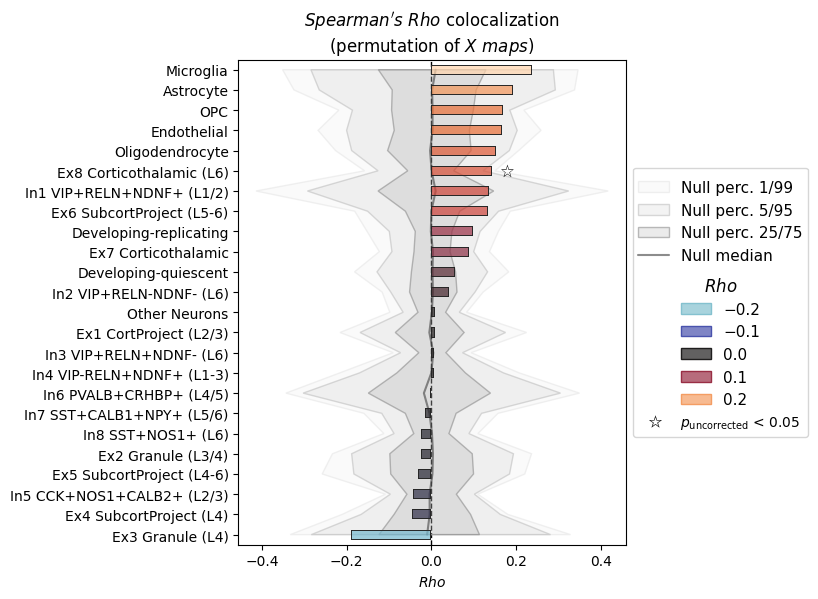

(<Figure size 500x630 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x1771fd880>)

In [7]:
nsp.plot(sort_by="coloc")

## XSEA with PET receptor sets

XSEA isn't limited to gene expression — you can use any reference dataset with a set structure. The PET dataset, for example, has neurotransmitter systems as sets. Running XSEA on it asks: does the pain map align more with the overall *serotonin system* than with the overall *dopamine system*, beyond what spatial autocorrelation can explain?

INFO | 30/06/26 13:10:26 | nispace.datasets: Loading pet maps.


INFO | 30/06/26 13:10:26 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 30/06/26 13:10:26 | nispace.datasets: Filtering maps by collection.


INFO | 30/06/26 13:10:26 | nispace.datasets: Filtered to 5 collection sets with between 3 and inf maps.


INFO | 30/06/26 13:10:26 | nispace.datasets: Loading and inner-merging data parcellated with 'Yan200' and 'TianS1'


...

INFO | 30/06/26 13:10:50 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 


INFO | 30/06/26 13:10:50 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | None      | False       | False       | 


INFO | 30/06/26 13:10:50 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | meffgalwey | False       | False       | 


INFO | 30/06/26 13:10:50 | nispace.api: Creating categorical plot for method spearman, colocalization stat rho.


INFO | 30/06/26 13:10:50 | nispace.plotting: Significance annotation: 0/5 p_uncorrected < 0.05, 0/5 p_meffgalwey < 0.05


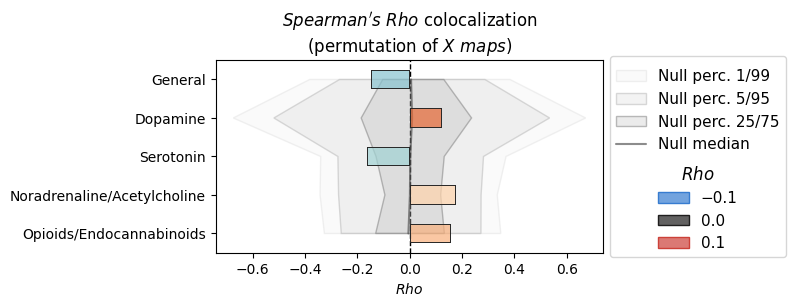

(<Figure size 500x250 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x1775f8be0>)

In [8]:
# For XSEA with PET, we need a collection with the set structure (neurotransmitter
# systems as sets). UniqueTracers is a JSON-format collection that gives a two-level
# ['set', 'map'] MultiIndex — exactly what XSEA needs to aggregate by system.
pet_unique = fetch_reference(
    "pet", parcellation="Yan200+TianS1", collection="UniqueTracers", print_references=False,
    set_size_range=(3, None) # when fetching set-based collections, some more parameters can be adjusted
) 

nsp_pet = NiSpace(
    x=pet_unique,
    y=pain_map,
    y_labels="Pain",
    parcellation="Yan200+TianS1",
    seed=42,
    n_proc=4
)
nsp_pet.fit()
nsp_pet.colocalize("spearman", xsea=True)
nsp_pet.permute("maps", maps_which="Y", n_perm=1000, p_tails="upper")
nsp_pet.correct_p()

nsp_pet.plot()

## The `xsea_aggregation_method` parameter

By default, XSEA aggregates individual map correlations by taking the mean. Alternatively, you can use `"median"` or `"absmean"`/`"absmedian"`, or even `"weightedmean"`. The latter only works when the input dataset does have a 3-level index with `set`, `map`, and `weight` as levels.  

In practice, `"mean"` is the most common and interpretable choice, but `"absmean"` (absolute mean) can be reasonable based on the context.

INFO | 30/06/26 13:10:50 | nispace.api: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***


INFO | 30/06/26 13:10:50 | nispace.api: Running 'spearman' colocalization.


INFO | 30/06/26 13:10:50 | nispace.api: Will perform X-set enrichment analysis (XSEA).


INFO | 30/06/26 13:10:50 | nispace.api: Using 5 sets with between 3 and 6 samples. Aggregating within-set colocalizations with: absmean.


INFO | 30/06/26 13:10:50 | nispace.api: Pre-ranking X and Y data.


...

INFO | 30/06/26 13:10:50 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 


INFO | 30/06/26 13:10:50 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | None      | False       | False       | 


INFO | 30/06/26 13:10:50 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | meffgalwey | False       | False       | 


INFO | 30/06/26 13:10:50 | nispace.api: Creating categorical plot for method spearman, colocalization stat rho.


INFO | 30/06/26 13:10:50 | nispace.plotting: Significance annotation: 0/5 p_uncorrected < 0.05, 0/5 p_meffgalwey < 0.05


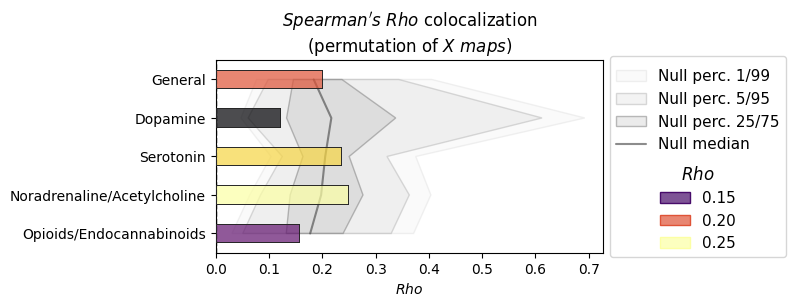

(<Figure size 500x250 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x17745b5b0>)

In [9]:
# absmean aggregation
nsp_pet.colocalize("spearman", xsea=True, xsea_aggregation_method="absmean")
nsp_pet.permute("maps", maps_which="Y", n_perm=1000, p_tails="upper") # one-tailed p value in this case
nsp_pet.plot()

## XSEA via the workflow

For a one-liner version:

INFO | 30/06/26 13:10:51 | nispace.workflows: Loading integrated mrna dataset as X data.


INFO | 30/06/26 13:10:51 | nispace.datasets: Loading mrna maps.


INFO | 30/06/26 13:10:51 | nispace.datasets: Loading integrated collection 'CellTypesPsychEncodeTPM' for dataset 'mrna'.


INFO | 30/06/26 13:10:51 | nispace.datasets: Filtering maps by collection.


INFO | 30/06/26 13:10:51 | nispace.datasets: Loading and inner-merging data parcellated with 'Yan100' and 'TianS1'


...

INFO | 30/06/26 13:11:06 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 


INFO | 30/06/26 13:11:06 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | None      | False       | False       | 


INFO | 30/06/26 13:11:06 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | meffgalwey | False       | False       | 


INFO | 30/06/26 13:11:06 | nispace.api: Creating categorical plot for method spearman, colocalization stat rho.


INFO | 30/06/26 13:11:06 | nispace.plotting: Significance annotation: 1/24 p_uncorrected < 0.05, 0/24 p_meffgalwey < 0.05


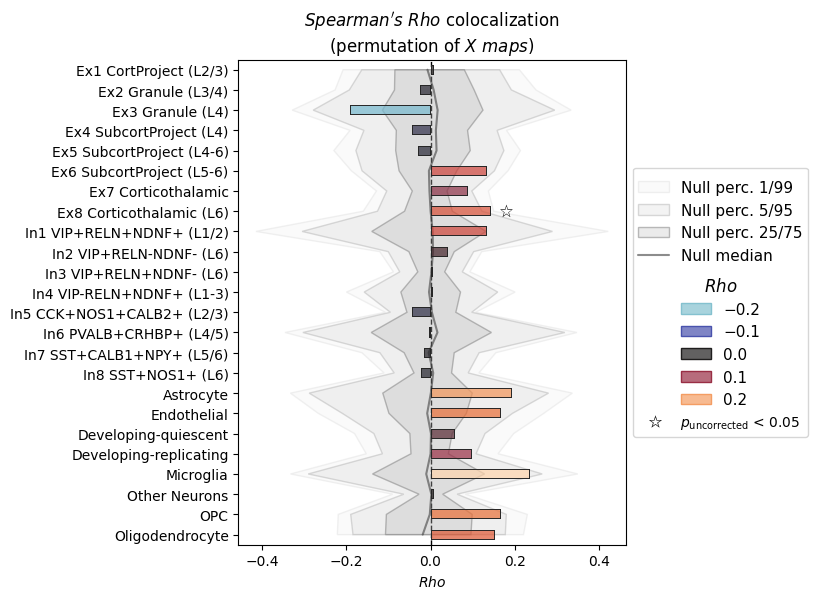

INFO | 30/06/26 13:11:06 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 


INFO | 30/06/26 13:11:06 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | None      | False       | False       | 


INFO | 30/06/26 13:11:06 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | meffgalwey | False       | False       | 


In [10]:
from nispace.workflows import xsea

nsp_wf = xsea(
    y={"Pain": pain_map},
    x="mrna",
    x_collection="CellTypesPsychEncodeTPM",
    parcellation="Yan100+TianS1",
    colocalization_method="spearman",
    n_perm=1000,
    seed=42,
    n_proc=4,
    return_nispace_only=True
)

## Summary

- XSEA aggregates individual map colocalizations within predefined sets and tests the set-level mean.
- Enable it by passing `xsea="mean"` (or `"median"`) to `colocalize()`.
- Permutation testing works the same as for individual maps: `permute("maps")`.
- The default null model (map permutation) avoids inflation from within-set co-expression, following Fulcher et al. (2021).
- ABAnnotate (the predecessor toolbox) used the same approach — XSEA in NiSpace is the generalized, multi-dataset version.
- For the workflow version: `xsea()`.

Next: [Notebook 11](intro11_advanced.ipynb) covers advanced topics: dimensionality reduction, multi-modal parcellations, alternative colocalization methods, and individual-level analyses.